# Loan Default Prediction - Complete ML Project
## Darshan University - AI/ML Subject
---

This project covers all 10 tasks as per the ML Project Guidelines:
1. Problem Definition and Dataset Exploration
2. Data Cleaning and Pre-processing
3. Model Creation (without library)
4. Model Evaluation
5. Advanced Model Training
6. Visualization of Metrics and Graphs
7. Flask Project Setup
8. Create Front End
9. Create Backend
10. Deployment

---
# TASK 1: Problem Definition and Dataset Exploration
---

## Problem Statement
**Objective:** Predict whether a loan applicant will default on their loan based on various features like age, income, credit score, employment status, etc.

**Type:** Binary Classification Problem
- Target Variable: `Default` (0 = No Default, 1 = Default)

**Business Impact:** Banks can use this model to:
- Reduce financial losses from loan defaults
- Make informed lending decisions
- Identify high-risk applicants

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load the Dataset
df = pd.read_csv('Loan_default.csv')
print("📊 Dataset loaded successfully!")
print(f"\n📏 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

📊 Dataset loaded successfully!

📏 Dataset Shape: 255347 rows × 18 columns


In [3]:
# First look at the data
print("🔍 First 5 Rows of Dataset:")
df.head()

🔍 First 5 Rows of Dataset:


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
# Dataset Information
print("📋 Dataset Information:")
print("="*50)
df.info()

📋 Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17

In [5]:
# Statistical Summary
print("📈 Statistical Summary of Numerical Features:")
df.describe()

📈 Statistical Summary of Numerical Features:


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [6]:
# Check Column Types
print("\n🏷️ Column Data Types:")
print("="*50)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n📊 Numerical Columns ({len(numerical_cols)}): {numerical_cols}")
print(f"\n📝 Categorical Columns ({len(categorical_cols)}): {categorical_cols}")


🏷️ Column Data Types:

📊 Numerical Columns (10): ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']

📝 Categorical Columns (8): ['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']



🎯 Target Variable Distribution (Default):
No Default (0): 225694 (88.39%)
Default (1): 29653 (11.61%)


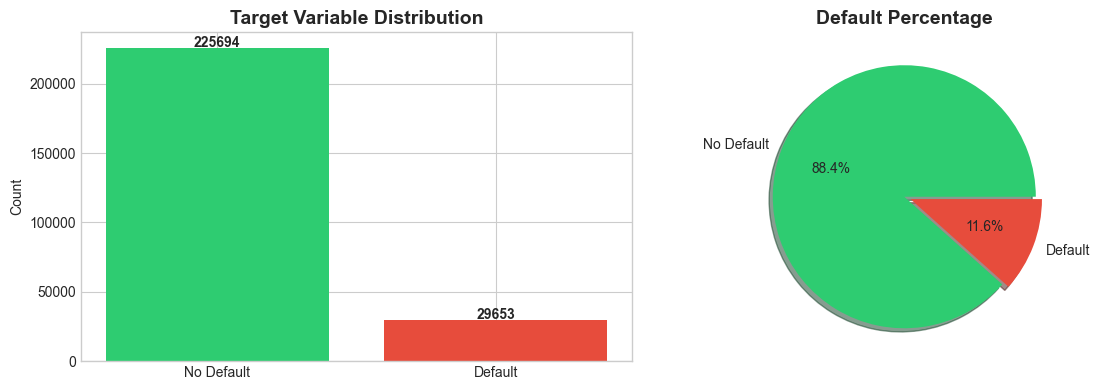

In [7]:
# Target Variable Distribution
print("\n🎯 Target Variable Distribution (Default):")
print("="*50)
target_counts = df['Default'].value_counts()
target_percentage = df['Default'].value_counts(normalize=True) * 100

print(f"No Default (0): {target_counts[0]} ({target_percentage[0]:.2f}%)")
print(f"Default (1): {target_counts[1]} ({target_percentage[1]:.2f}%)")

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2ecc71', '#e74c3c']

# Bar plot
ax[0].bar(['No Default', 'Default'], target_counts.values, color=colors)
ax[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax[0].text(i, v + 1000, str(v), ha='center', fontweight='bold')

# Pie chart
ax[1].pie(target_counts.values, labels=['No Default', 'Default'], autopct='%1.1f%%', 
          colors=colors, explode=[0, 0.05], shadow=True)
ax[1].set_title('Default Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# Initial Observations
print("\n📝 INITIAL OBSERVATIONS:")
print("="*60)
print("""
1. Dataset has 255,347 loan records with 18 features
2. Target variable 'Default' is binary (0/1)
3. Dataset is imbalanced (~88% No Default, ~12% Default)
4. Features include:
   - Demographics: Age, Education, MaritalStatus
   - Financial: Income, LoanAmount, CreditScore, DTIRatio
   - Employment: MonthsEmployed, EmploymentType
   - Loan Details: InterestRate, LoanTerm, LoanPurpose
   - Other: HasMortgage, HasDependents, HasCoSigner
5. LoanID is an identifier (will be dropped)
6. Mix of numerical and categorical features
""")


📝 INITIAL OBSERVATIONS:

1. Dataset has 255,347 loan records with 18 features
2. Target variable 'Default' is binary (0/1)
3. Dataset is imbalanced (~88% No Default, ~12% Default)
4. Features include:
   - Demographics: Age, Education, MaritalStatus
   - Financial: Income, LoanAmount, CreditScore, DTIRatio
   - Employment: MonthsEmployed, EmploymentType
   - Loan Details: InterestRate, LoanTerm, LoanPurpose
   - Other: HasMortgage, HasDependents, HasCoSigner
5. LoanID is an identifier (will be dropped)
6. Mix of numerical and categorical features



---
# TASK 2: Data Cleaning and Pre-processing
---

In [9]:
# Check for Missing Values
print("🔍 Missing Values Analysis:")
print("="*50)
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage': missing_percent})
print(missing_df[missing_df['Missing Values'] > 0])
if missing.sum() == 0:
    print("\n✅ No missing values found in the dataset!")

🔍 Missing Values Analysis:
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []

✅ No missing values found in the dataset!


In [10]:
# Check for Duplicates
print("\n🔍 Duplicate Records:")
print("="*50)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✅ Removed {duplicates} duplicate rows")
else:
    print("✅ No duplicates found!")


🔍 Duplicate Records:
Number of duplicate rows: 0
✅ No duplicates found!


In [11]:
# Drop LoanID column (not useful for prediction)
print("\n🗑️ Dropping LoanID column (identifier, not useful for prediction)")
df = df.drop('LoanID', axis=1)
print(f"✅ New shape: {df.shape}")


🗑️ Dropping LoanID column (identifier, not useful for prediction)
✅ New shape: (255347, 17)


In [12]:
# Identify Outliers using IQR method
print("\n📊 Outlier Detection (IQR Method):")
print("="*50)

numerical_features = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 
                      'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

outlier_summary = []
for col in numerical_features:
    count, lb, ub = detect_outliers_iqr(df, col)
    outlier_summary.append({'Feature': col, 'Outliers': count, 'Lower Bound': round(lb, 2), 'Upper Bound': round(ub, 2)})

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)


📊 Outlier Detection (IQR Method):
          Feature  Outliers  Lower Bound  Upper Bound
0             Age         0        -6.50        93.50
1          Income         0    -52264.75    217309.25
2      LoanAmount         0   -118087.50    373228.50
3     CreditScore         0        24.50      1124.50
4  MonthsEmployed         0       -60.00       180.00
5  NumCreditLines         0         0.50         4.50
6    InterestRate         0        -9.45        36.47
7        LoanTerm         0       -12.00        84.00
8        DTIRatio         0        -0.30         1.30


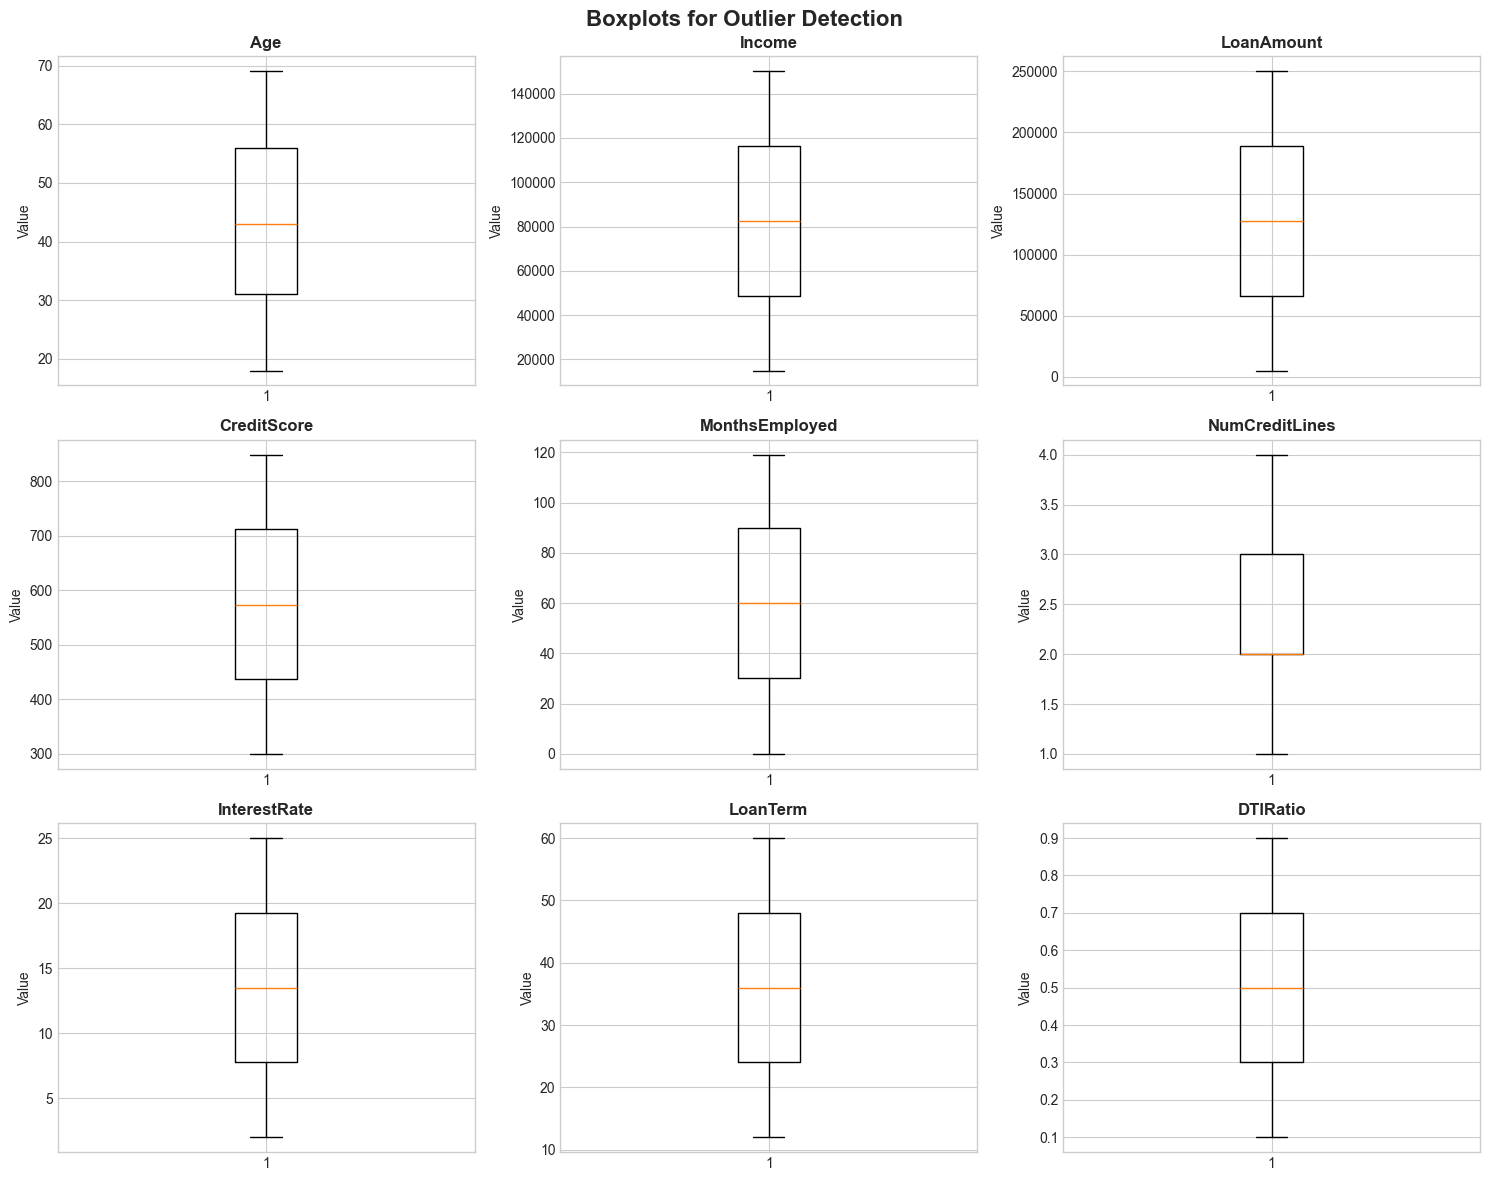

In [13]:
# Visualize Outliers with Box Plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots for Outlier Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Handle Outliers using Capping (Winsorization)
print("\n🔧 Handling Outliers using Capping Method:")
print("="*50)

def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)
    return data

# Cap outliers for columns with significant outliers
for col in ['Income', 'LoanAmount', 'MonthsEmployed']:
    df = cap_outliers(df, col)
    print(f"✅ Capped outliers in {col}")

print("\n✅ Outlier handling complete!")


🔧 Handling Outliers using Capping Method:
✅ Capped outliers in Income
✅ Capped outliers in LoanAmount
✅ Capped outliers in MonthsEmployed

✅ Outlier handling complete!


In [15]:
# Encode Categorical Variables
print("\n🔄 Encoding Categorical Variables:")
print("="*50)

# Display unique values in categorical columns
cat_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 
            'HasDependents', 'LoanPurpose', 'HasCoSigner']

for col in cat_cols:
    print(f"{col}: {df[col].unique()}")


🔄 Encoding Categorical Variables:
Education: <StringArray>
['Bachelor's', 'Master's', 'High School', 'PhD']
Length: 4, dtype: str
EmploymentType: <StringArray>
['Full-time', 'Unemployed', 'Self-employed', 'Part-time']
Length: 4, dtype: str
MaritalStatus: <StringArray>
['Divorced', 'Married', 'Single']
Length: 3, dtype: str
HasMortgage: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
HasDependents: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
LoanPurpose: <StringArray>
['Other', 'Auto', 'Business', 'Home', 'Education']
Length: 5, dtype: str
HasCoSigner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [16]:
# Label Encoding for binary categorical variables
from sklearn.preprocessing import LabelEncoder

binary_cols = ['HasMortgage', 'HasDependents', 'HasCoSigner']
le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f"✅ Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

✅ Encoded HasMortgage: {'No': np.int64(0), 'Yes': np.int64(1)}
✅ Encoded HasDependents: {'No': np.int64(0), 'Yes': np.int64(1)}
✅ Encoded HasCoSigner: {'No': np.int64(0), 'Yes': np.int64(1)}


In [17]:
# One-Hot Encoding for multi-class categorical variables
print("\n🔄 One-Hot Encoding for Multi-class Variables:")

multi_cat_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose']
df_encoded = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

print(f"\n✅ Shape after encoding: {df_encoded.shape}")
print(f"\nNew columns added: {[col for col in df_encoded.columns if col not in df.columns]}")


🔄 One-Hot Encoding for Multi-class Variables:

✅ Shape after encoding: (255347, 25)

New columns added: ['Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other']


In [18]:
# Feature Scaling / Normalization
print("\n📏 Feature Scaling (StandardScaler):")
print("="*50)

from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_encoded.drop('Default', axis=1)
y = df_encoded['Default']

# Scale numerical features
scaler = StandardScaler()
numerical_to_scale = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 
                      'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

X_scaled = X.copy()
X_scaled[numerical_to_scale] = scaler.fit_transform(X[numerical_to_scale])

print("✅ Features scaled using StandardScaler")
print(f"\nScaled features sample:")
X_scaled[numerical_to_scale].head()


📏 Feature Scaling (StandardScaler):
✅ Features scaled using StandardScaler

Scaled features sample:


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio
0,0.833990,0.089693,-1.086833,-0.341492,0.590533,1.341937,0.261771,-0.001526,-0.260753
1,1.701221,-0.823021,-0.044309,-0.731666,-1.285731,-1.343791,-1.308350,1.412793,0.778585
2,0.166888,0.043854,0.022715,-0.775718,-0.968209,0.446694,1.156831,-0.708685,-0.823728
3,-0.767053,-1.303452,-1.168538,1.061875,-1.718715,0.446694,-0.967805,-0.708685,-1.170174
4,1.100830,-1.592855,-1.671921,0.369631,-1.487790,1.341937,-1.052188,0.705634,0.995114


In [19]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("\n📊 Train-Test Split:")
print("="*50)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"\nTarget distribution in training set:")
print(y_train.value_counts(normalize=True).round(3))


📊 Train-Test Split:
Training set: 204277 samples (80.0%)
Testing set: 51070 samples (20.0%)

Target distribution in training set:
Default
0    0.884
1    0.116
Name: proportion, dtype: float64


In [20]:
# EDA - Exploratory Data Analysis
print("\n📊 EXPLORATORY DATA ANALYSIS (EDA)")
print("="*50)


📊 EXPLORATORY DATA ANALYSIS (EDA)


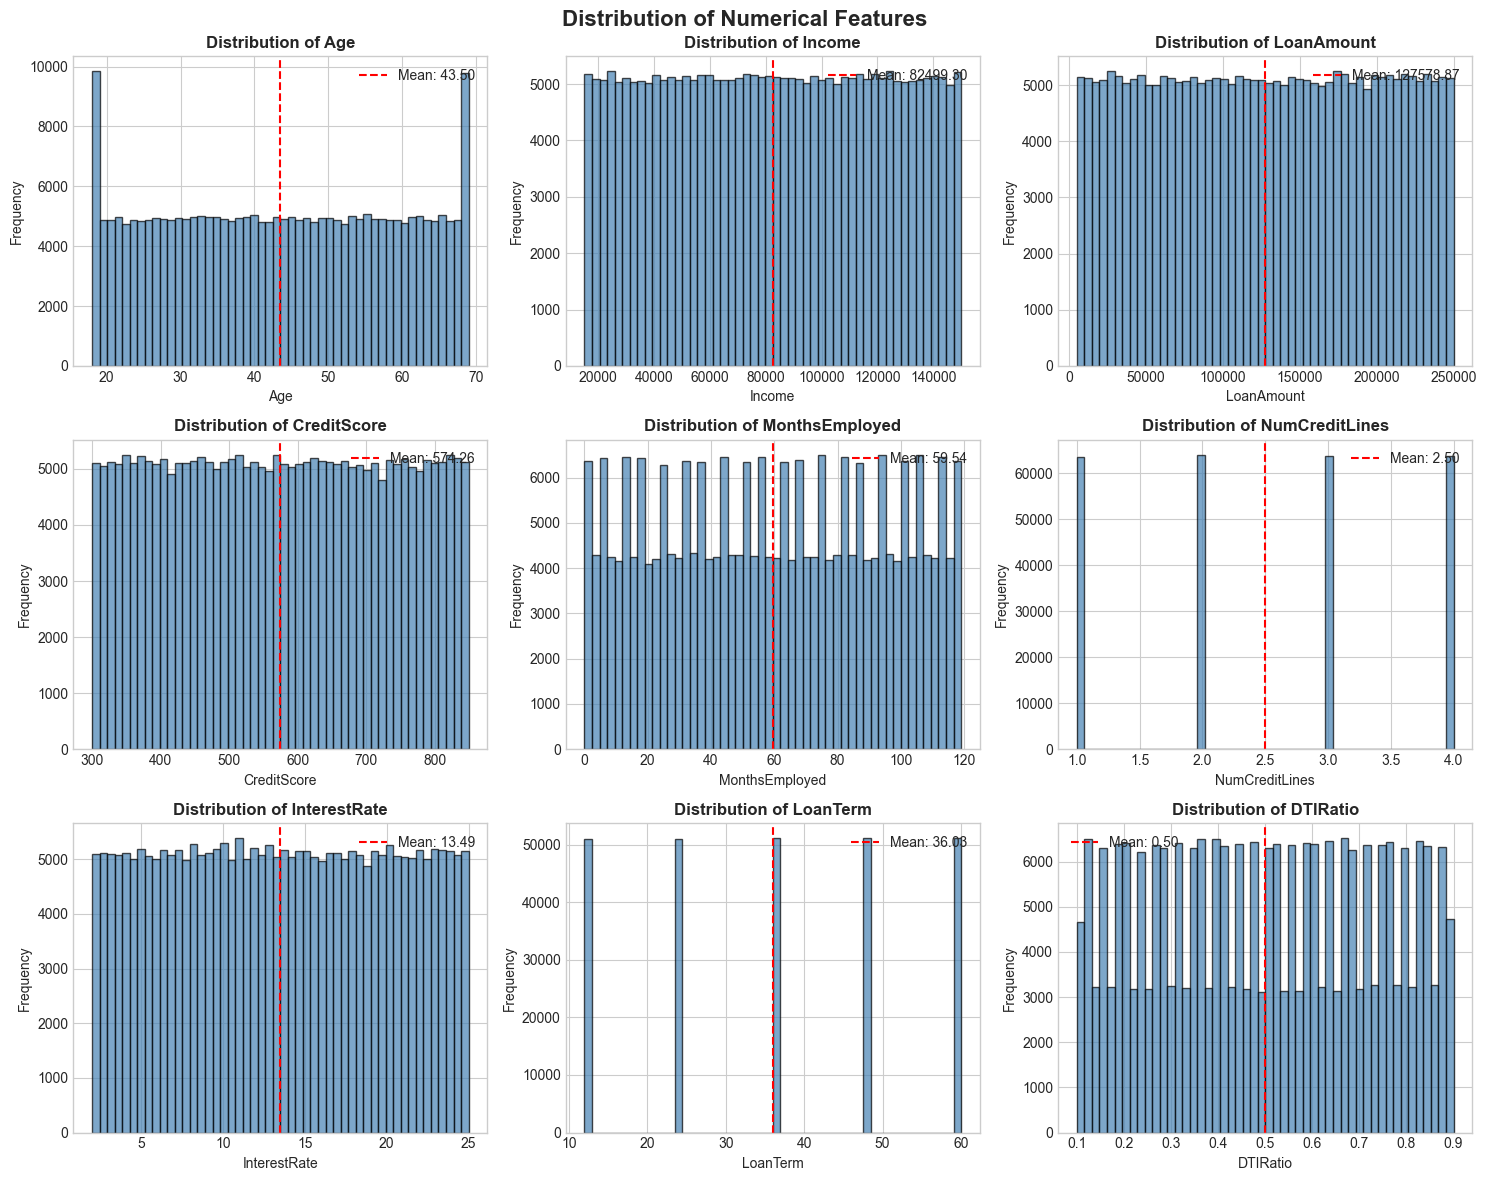

In [21]:
# Distribution of Numerical Features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    axes[i].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i].legend()

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

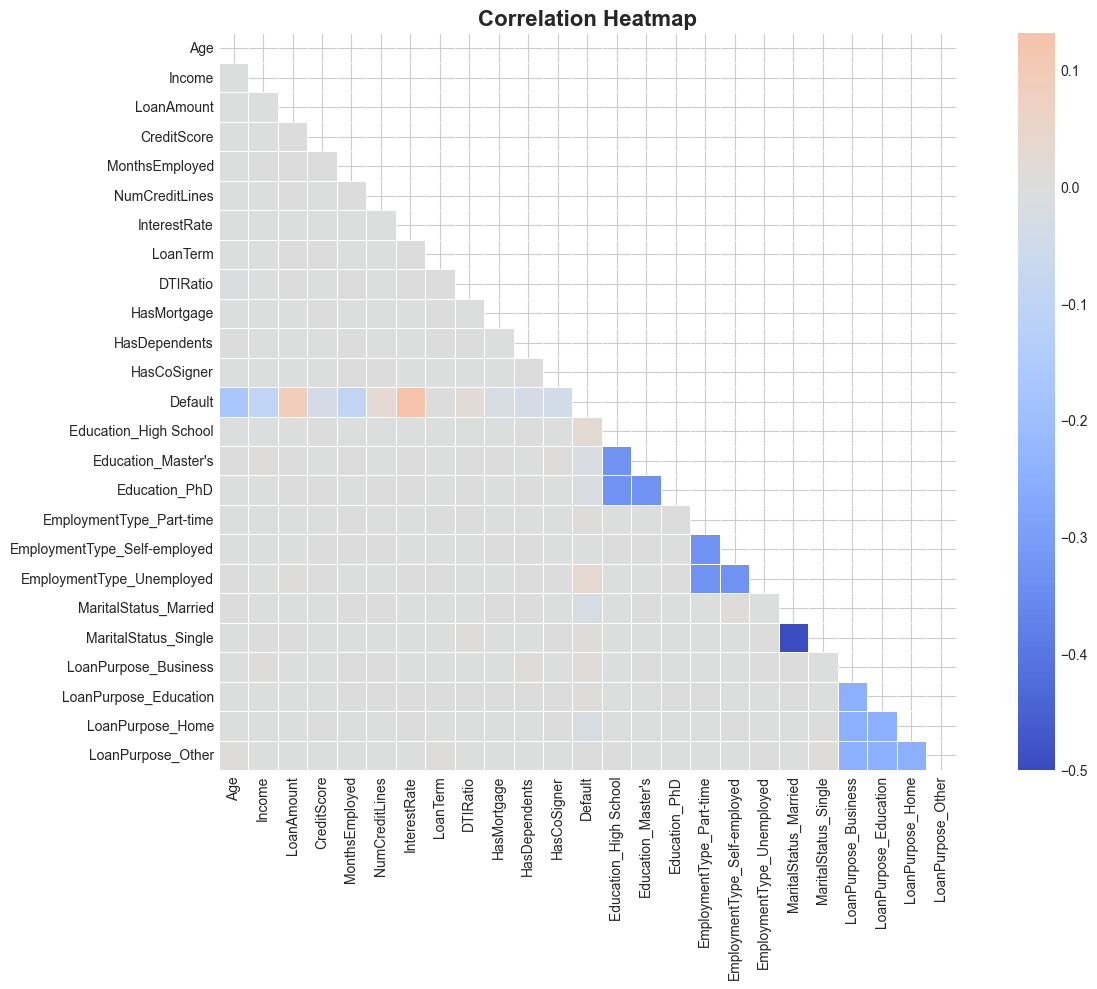


🎯 Top Features Correlated with Default:
InterestRate                 0.131273
LoanAmount                   0.086659
EmploymentType_Unemployed    0.034957
NumCreditLines               0.028330
Education_High School        0.022831
DTIRatio                     0.019236
LoanPurpose_Business         0.011162
MaritalStatus_Single         0.006607
EmploymentType_Part-time     0.006372
LoanPurpose_Education        0.003512
Name: Default, dtype: float64


In [22]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
print("\n🎯 Top Features Correlated with Default:")
target_corr = correlation_matrix['Default'].sort_values(ascending=False)
print(target_corr[1:11])

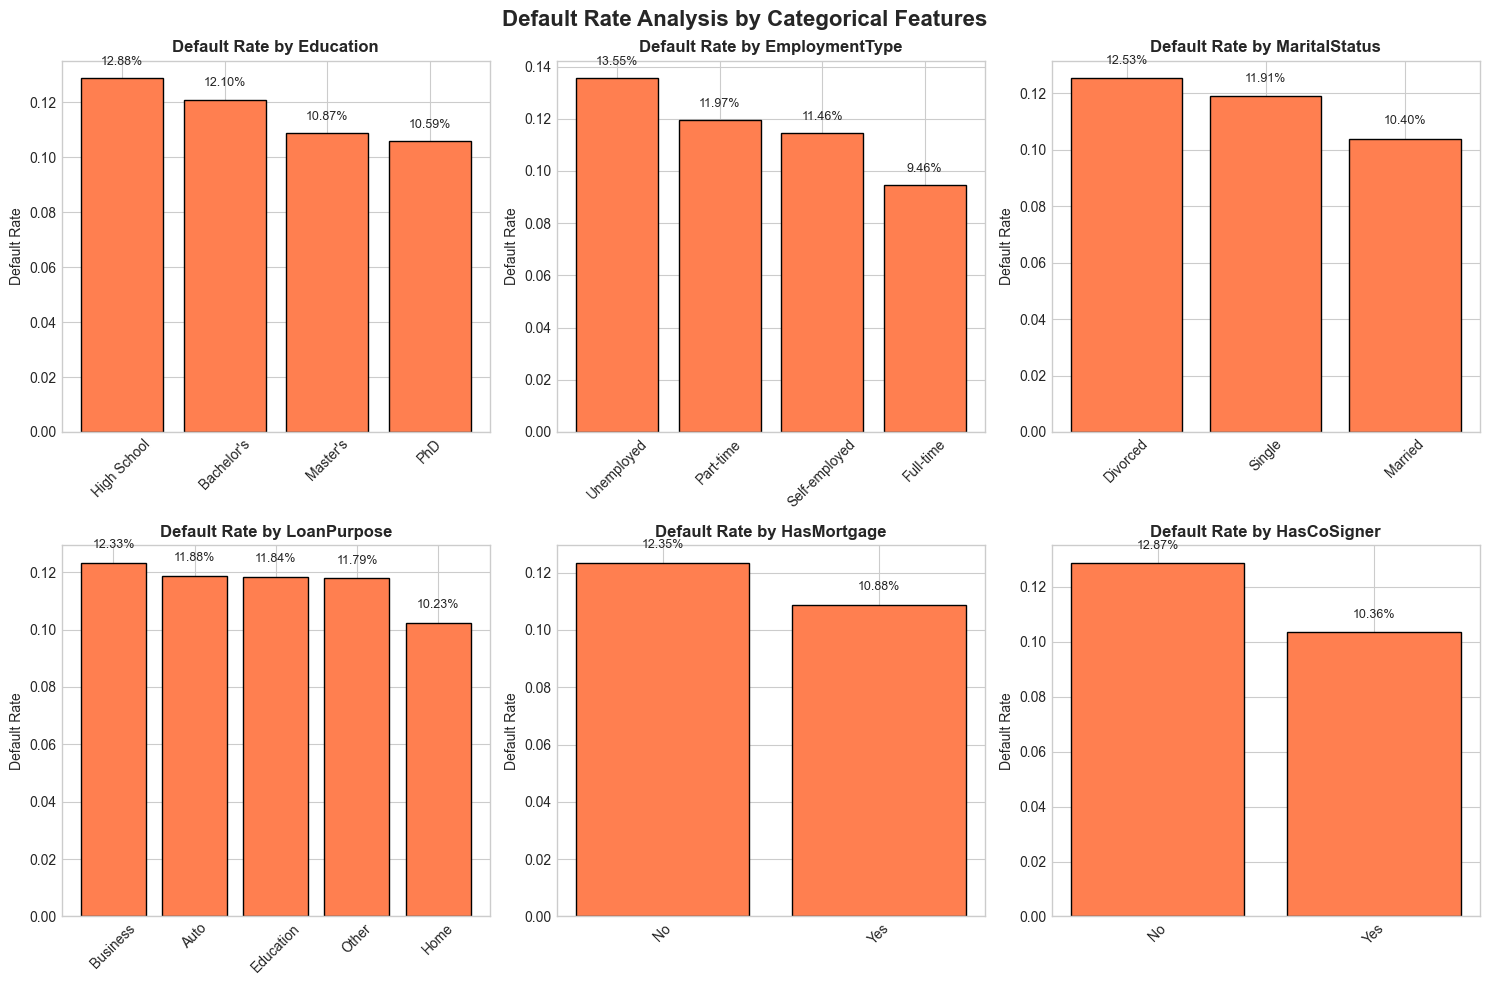

In [23]:
# Default Rate by Categorical Features
original_df = pd.read_csv('Loan_default.csv')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

cat_features = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose', 'HasMortgage', 'HasCoSigner']

for i, col in enumerate(cat_features):
    default_rate = original_df.groupby(col)['Default'].mean().sort_values(ascending=False)
    axes[i].bar(default_rate.index, default_rate.values, color='coral', edgecolor='black')
    axes[i].set_title(f'Default Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Default Rate')
    axes[i].tick_params(axis='x', rotation=45)
    for j, v in enumerate(default_rate.values):
        axes[i].text(j, v + 0.005, f'{v:.2%}', ha='center', fontsize=9)

plt.suptitle('Default Rate Analysis by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
# TASK 3: Model Creation (Without Library)
---

Implementing **Logistic Regression from scratch** without using sklearn's LogisticRegression

In [24]:
# Logistic Regression from Scratch
print("🔧 LOGISTIC REGRESSION FROM SCRATCH")
print("="*50)

class LogisticRegressionScratch:
    """
    Logistic Regression implemented from scratch using Gradient Descent.
    
    Mathematical Foundation:
    - Sigmoid function: σ(z) = 1 / (1 + e^(-z))
    - Hypothesis: h(x) = σ(w.T @ x + b)
    - Cost Function: J(w) = -1/m * Σ[y*log(h(x)) + (1-y)*log(1-h(x))]
    - Gradient Descent: w = w - α * ∂J/∂w
    """
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []
        
    def sigmoid(self, z):
        """Sigmoid activation function"""
        # Clip values to prevent overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def compute_cost(self, y, y_pred):
        """Binary Cross-Entropy Loss"""
        m = len(y)
        # Add small epsilon to prevent log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        cost = -1/m * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        return cost
    
    def fit(self, X, y):
        """Train the model using Gradient Descent"""
        # Convert to numpy arrays with float64 dtype to ensure compatibility with numpy functions
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.float64)
        
        # Initialize parameters
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Gradient Descent
        for i in range(self.n_iterations):
            # Forward propagation
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)
            
            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Record cost
            cost = self.compute_cost(y, y_pred)
            self.cost_history.append(cost)
            
            # Print progress
            if (i + 1) % 100 == 0:
                print(f"Iteration {i+1}/{self.n_iterations}, Cost: {cost:.6f}")
    
    def predict_proba(self, X):
        """Predict probabilities"""
        X = np.array(X, dtype=np.float64)
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)
    
    def predict(self, X, threshold=0.5):
        """Predict class labels"""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

print("✅ Logistic Regression class defined!")

🔧 LOGISTIC REGRESSION FROM SCRATCH
✅ Logistic Regression class defined!


In [25]:
# Train the model from scratch
print("\n🚀 Training Logistic Regression from Scratch...")
print("="*50)

# Use a subset for faster training (scratch implementation is slower)
X_train_sample = X_train.iloc[:50000]
y_train_sample = y_train.iloc[:50000]

# Initialize and train
lr_scratch = LogisticRegressionScratch(learning_rate=0.1, n_iterations=500)
lr_scratch.fit(X_train_sample, y_train_sample)

print("\n✅ Model trained successfully!")


🚀 Training Logistic Regression from Scratch...
Iteration 100/500, Cost: 0.330053
Iteration 200/500, Cost: 0.322213
Iteration 300/500, Cost: 0.320114
Iteration 400/500, Cost: 0.319224
Iteration 500/500, Cost: 0.318694

✅ Model trained successfully!


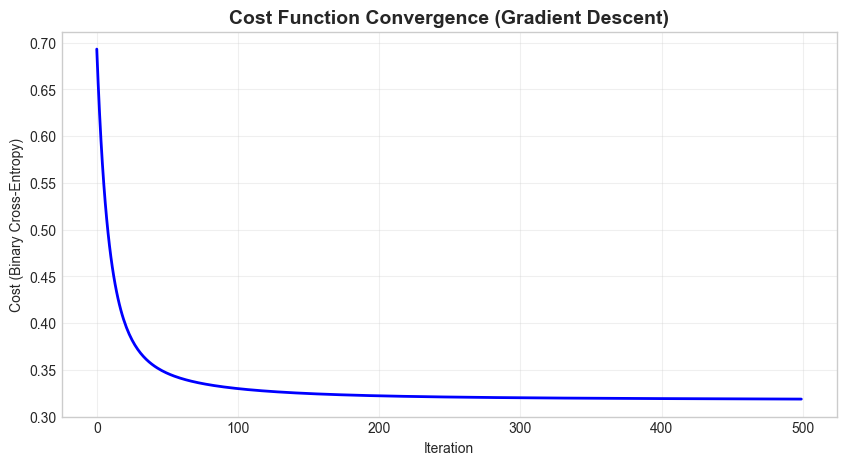

Initial Cost: 0.693147
Final Cost: 0.318694


In [26]:
# Plot Cost Function Convergence
plt.figure(figsize=(10, 5))
plt.plot(lr_scratch.cost_history, color='blue', linewidth=2)
plt.title('Cost Function Convergence (Gradient Descent)', fontsize=14, fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('Cost (Binary Cross-Entropy)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial Cost: {lr_scratch.cost_history[0]:.6f}")
print(f"Final Cost: {lr_scratch.cost_history[-1]:.6f}")

In [27]:
# Make predictions with scratch model
y_pred_scratch = lr_scratch.predict(X_test)
y_pred_proba_scratch = lr_scratch.predict_proba(X_test)

print("\n📊 Predictions from Scratch Model:")
print(f"Sample predictions: {y_pred_scratch[:10]}")
print(f"Sample probabilities: {y_pred_proba_scratch[:10].round(4)}")


📊 Predictions from Scratch Model:
Sample predictions: [0 0 0 0 0 0 0 0 0 0]
Sample probabilities: [0.0372 0.0278 0.0647 0.1458 0.089  0.0103 0.3251 0.0894 0.2798 0.1196]


---
# TASK 4: Model Evaluation
---

In [28]:
# Model Evaluation Functions from Scratch
print("📊 MODEL EVALUATION")
print("="*50)

def calculate_metrics(y_true, y_pred):
    """Calculate all classification metrics from scratch"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Confusion Matrix components
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    # Metrics
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'Confusion Matrix': {'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN},
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall (Sensitivity)': recall,
        'Specificity': specificity,
        'F1-Score': f1_score
    }

# Calculate metrics for scratch model
metrics_scratch = calculate_metrics(y_test, y_pred_scratch)

print("\n📈 Logistic Regression (From Scratch) - Metrics:")
print("-"*50)
print(f"Accuracy:    {metrics_scratch['Accuracy']:.4f} ({metrics_scratch['Accuracy']*100:.2f}%)")
print(f"Precision:   {metrics_scratch['Precision']:.4f}")
print(f"Recall:      {metrics_scratch['Recall (Sensitivity)']:.4f}")
print(f"Specificity: {metrics_scratch['Specificity']:.4f}")
print(f"F1-Score:    {metrics_scratch['F1-Score']:.4f}")
print(f"\nConfusion Matrix: {metrics_scratch['Confusion Matrix']}")

📊 MODEL EVALUATION

📈 Logistic Regression (From Scratch) - Metrics:
--------------------------------------------------
Accuracy:    0.8845 (88.45%)
Precision:   0.5383
Recall:      0.0356
Specificity: 0.9960
F1-Score:    0.0667

Confusion Matrix: {'TP': np.int64(211), 'TN': np.int64(44958), 'FP': np.int64(181), 'FN': np.int64(5720)}


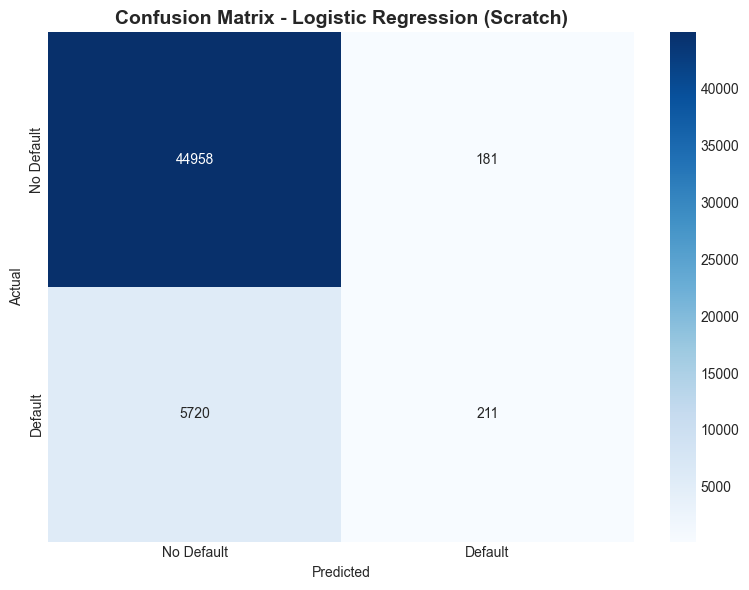

In [29]:
# Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_scratch)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Logistic Regression (Scratch)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

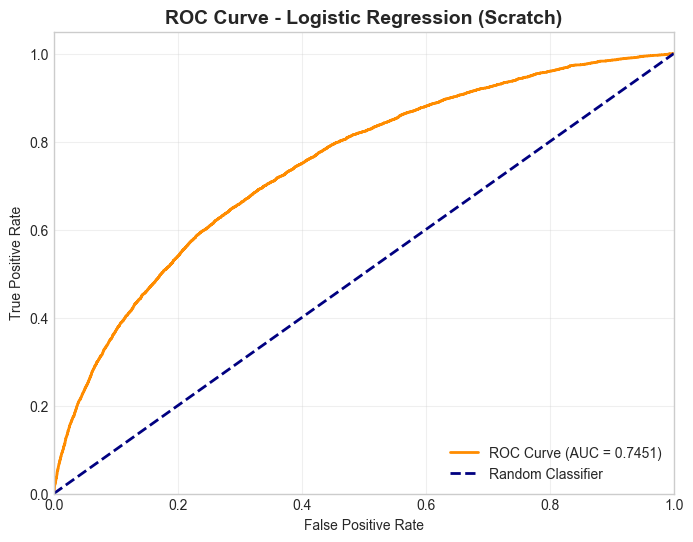


📊 AUC-ROC Score: 0.7451


In [30]:
# ROC Curve and AUC
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_scratch)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (Scratch)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n📊 AUC-ROC Score: {roc_auc:.4f}")

In [31]:
# Check for Overfitting/Underfitting
print("\n🔍 OVERFITTING/UNDERFITTING ANALYSIS")
print("="*50)

# Training accuracy
y_train_pred = lr_scratch.predict(X_train_sample)
train_acc = np.mean(y_train_pred == y_train_sample)

# Test accuracy
test_acc = metrics_scratch['Accuracy']

print(f"Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Testing Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"\nDifference: {abs(train_acc - test_acc):.4f}")

if abs(train_acc - test_acc) < 0.02:
    print("\n✅ Model is WELL-FITTED (Good generalization)")
elif train_acc > test_acc + 0.05:
    print("\n⚠️ Model might be OVERFITTING (High variance)")
    print("   Solutions: More data, regularization, simpler model")
else:
    print("\n⚠️ Model might be UNDERFITTING (High bias)")
    print("   Solutions: More features, complex model, more training")


🔍 OVERFITTING/UNDERFITTING ANALYSIS
Training Accuracy: 0.8847 (88.47%)
Testing Accuracy:  0.8845 (88.45%)

Difference: 0.0002

✅ Model is WELL-FITTED (Good generalization)


---
# TASK 5: Advanced Model Training
---

Training multiple advanced models with hyperparameter tuning and cross-validation

In [32]:
# Import Advanced Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score

print("🚀 ADVANCED MODEL TRAINING")
print("="*50)

🚀 ADVANCED MODEL TRAINING


In [33]:
# Use a sample for faster training
sample_size = 50000
X_train_adv = X_train.iloc[:sample_size]
y_train_adv = y_train.iloc[:sample_size]

print(f"Using {sample_size} samples for advanced model training")

Using 50000 samples for advanced model training


In [34]:
# 1. Logistic Regression (sklearn)
print("\n📌 1. Logistic Regression (sklearn)")
print("-"*40)

lr_sklearn = LogisticRegression(max_iter=1000, random_state=42)
lr_sklearn.fit(X_train_adv, y_train_adv)
y_pred_lr = lr_sklearn.predict(X_test)

# Cross-validation
cv_scores_lr = cross_val_score(lr_sklearn, X_train_adv, y_train_adv, cv=5, scoring='accuracy')
print(f"CV Accuracy: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std()*2:.4f})")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")


📌 1. Logistic Regression (sklearn)
----------------------------------------
CV Accuracy: 0.8853 (+/- 0.0016)
Test Accuracy: 0.8852
F1-Score: 0.0651


In [35]:
# 2. Decision Tree
print("\n📌 2. Decision Tree Classifier")
print("-"*40)

dt_clf = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_clf.fit(X_train_adv, y_train_adv)
y_pred_dt = dt_clf.predict(X_test)

cv_scores_dt = cross_val_score(dt_clf, X_train_adv, y_train_adv, cv=5, scoring='accuracy')
print(f"CV Accuracy: {cv_scores_dt.mean():.4f} (+/- {cv_scores_dt.std()*2:.4f})")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.4f}")


📌 2. Decision Tree Classifier
----------------------------------------
CV Accuracy: 0.8701 (+/- 0.0050)
Test Accuracy: 0.8713
F1-Score: 0.1368


In [36]:
# 3. Random Forest with Hyperparameter Tuning
print("\n📌 3. Random Forest Classifier (with GridSearchCV)")
print("-"*40)

# Define parameter grid
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15],
    'min_samples_split': [5, 10]
}

rf_clf = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(rf_clf, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train_adv, y_train_adv)

print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Best CV Accuracy: {grid_search_rf.best_score_:.4f}")

# Best model predictions
y_pred_rf = grid_search_rf.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")


📌 3. Random Forest Classifier (with GridSearchCV)
----------------------------------------
Best Parameters: {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Accuracy: 0.8852
Test Accuracy: 0.8852
F1-Score: 0.0359


In [37]:
# 4. Gradient Boosting
print("\n📌 4. Gradient Boosting Classifier")
print("-"*40)

gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_clf.fit(X_train_adv, y_train_adv)
y_pred_gb = gb_clf.predict(X_test)

cv_scores_gb = cross_val_score(gb_clf, X_train_adv, y_train_adv, cv=3, scoring='accuracy')
print(f"CV Accuracy: {cv_scores_gb.mean():.4f} (+/- {cv_scores_gb.std()*2:.4f})")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_gb):.4f}")


📌 4. Gradient Boosting Classifier
----------------------------------------
CV Accuracy: 0.8843 (+/- 0.0005)
Test Accuracy: 0.8859
F1-Score: 0.1294


In [38]:
# 5. K-Nearest Neighbors with Hyperparameter Tuning
print("\n📌 5. K-Nearest Neighbors (with GridSearchCV)")
print("-"*40)

param_grid_knn = {'n_neighbors': [3, 5, 7, 9]}
knn_clf = KNeighborsClassifier()
grid_search_knn = GridSearchCV(knn_clf, param_grid_knn, cv=3, scoring='accuracy')
grid_search_knn.fit(X_train_adv, y_train_adv)

print(f"Best K: {grid_search_knn.best_params_}")
y_pred_knn = grid_search_knn.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn):.4f}")


📌 5. K-Nearest Neighbors (with GridSearchCV)
----------------------------------------
Best K: {'n_neighbors': 9}
Test Accuracy: 0.8808
F1-Score: 0.0674


In [39]:
# Model Comparison Summary
print("\n📊 MODEL COMPARISON SUMMARY")
print("="*60)

models_results = {
    'Model': ['Logistic Regression (Scratch)', 'Logistic Regression (sklearn)', 
              'Decision Tree', 'Random Forest', 'Gradient Boosting', 'KNN'],
    'Test Accuracy': [
        metrics_scratch['Accuracy'],
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_knn)
    ],
    'F1-Score': [
        metrics_scratch['F1-Score'],
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_knn)
    ]
}

results_df = pd.DataFrame(models_results)
results_df = results_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

best_model = results_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model}")


📊 MODEL COMPARISON SUMMARY
                        Model  Test Accuracy  F1-Score
            Gradient Boosting       0.885882  0.129370
                Random Forest       0.885236  0.035861
Logistic Regression (sklearn)       0.885216  0.065072
Logistic Regression (Scratch)       0.884453  0.066740
                          KNN       0.880811  0.067412
                Decision Tree       0.871294  0.136835

🏆 Best Model: Gradient Boosting


---
# TASK 6: Visualization of Metrics and Graphs
---

📊 PERFORMANCE VISUALIZATION


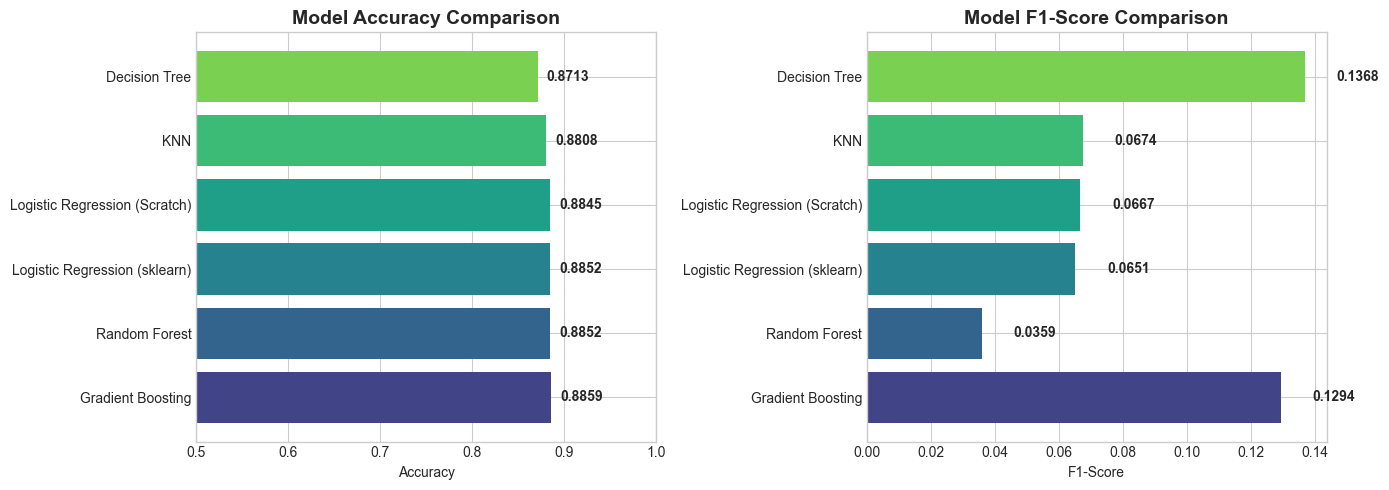

In [40]:
# 1. Model Accuracy Comparison Bar Chart
print("📊 PERFORMANCE VISUALIZATION")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results_df)))
axes[0].barh(results_df['Model'], results_df['Test Accuracy'], color=colors)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlim([0.5, 1.0])
for i, v in enumerate(results_df['Test Accuracy']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

# F1-Score comparison
axes[1].barh(results_df['Model'], results_df['F1-Score'], color=colors)
axes[1].set_xlabel('F1-Score')
axes[1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
for i, v in enumerate(results_df['F1-Score']):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

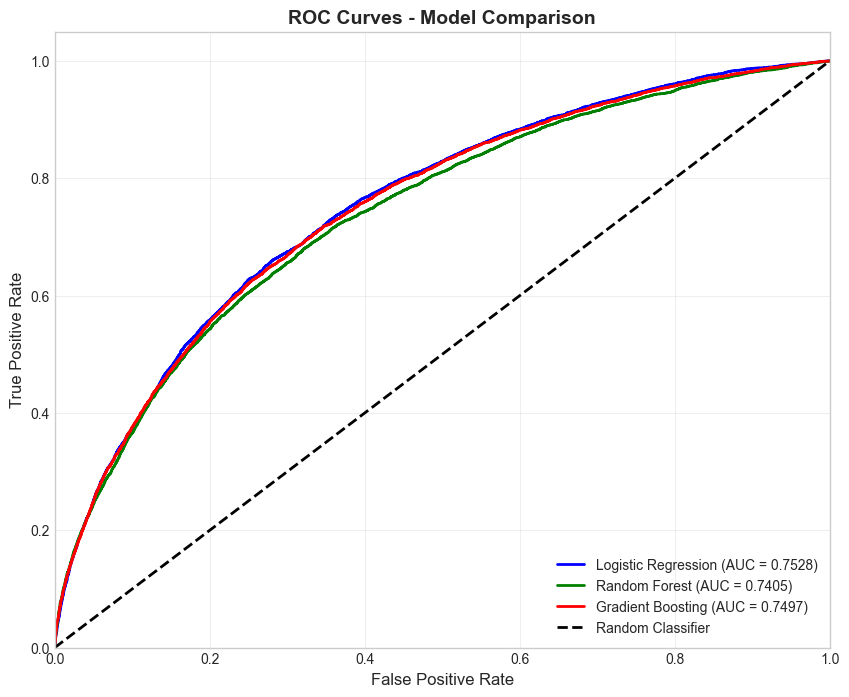

In [41]:
# 2. Multiple ROC Curves
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# Get probability predictions for each model
models_for_roc = [
    ('Logistic Regression', lr_sklearn),
    ('Random Forest', grid_search_rf.best_estimator_),
    ('Gradient Boosting', gb_clf),
]

colors_roc = ['blue', 'green', 'red']

for (name, model), color in zip(models_for_roc, colors_roc):
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

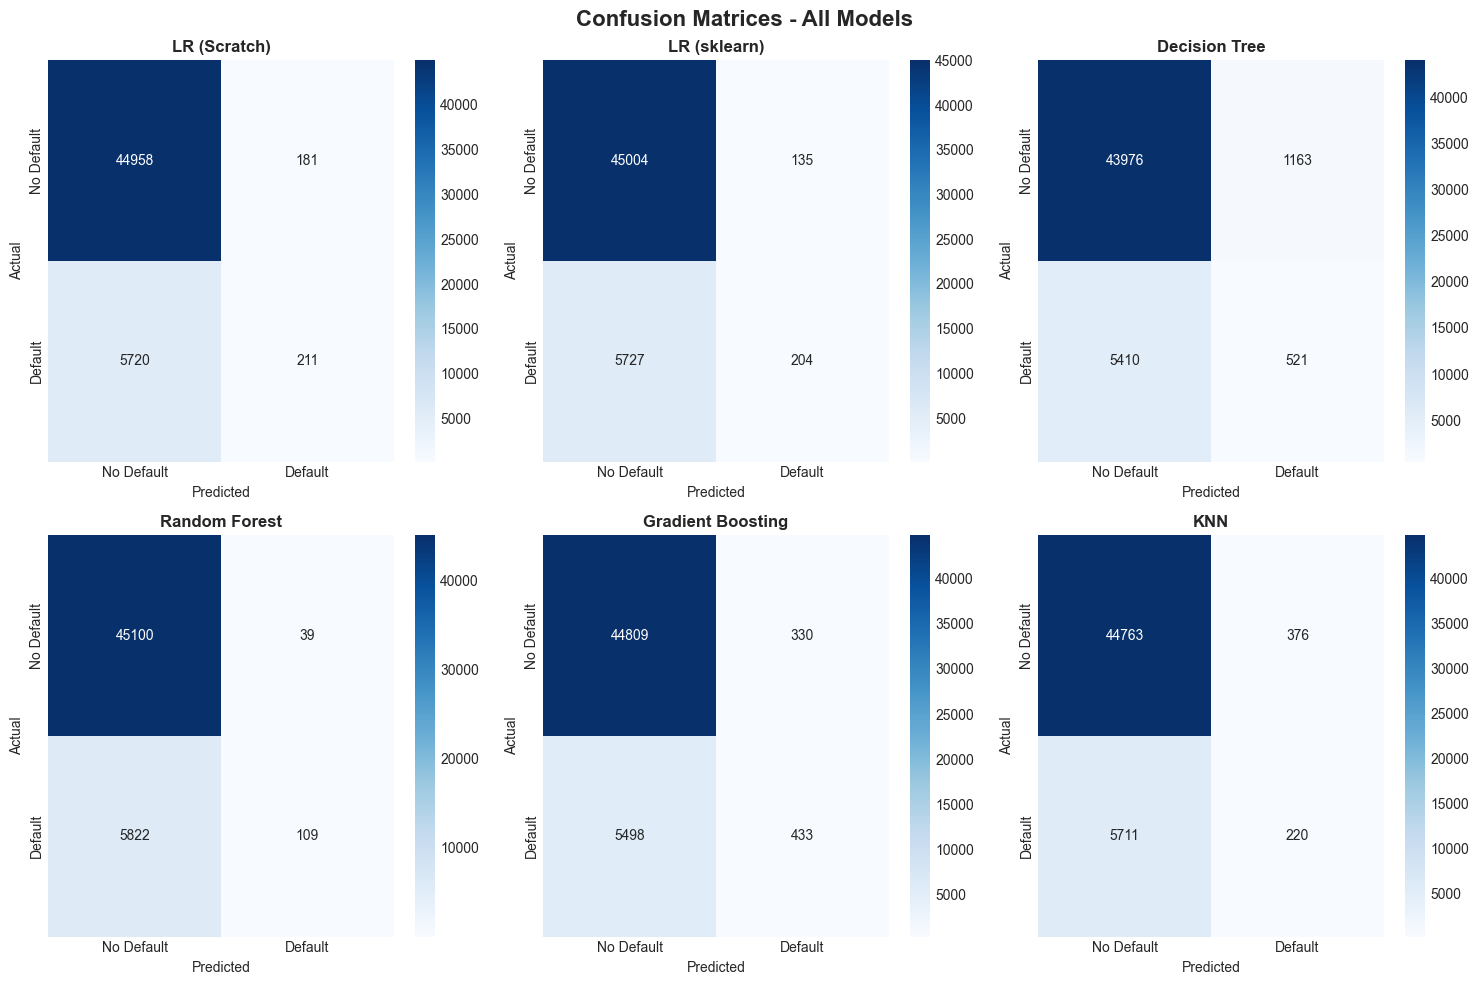

In [42]:
# 3. Confusion Matrices for All Models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

predictions = [
    ('LR (Scratch)', y_pred_scratch),
    ('LR (sklearn)', y_pred_lr),
    ('Decision Tree', y_pred_dt),
    ('Random Forest', y_pred_rf),
    ('Gradient Boosting', y_pred_gb),
    ('KNN', y_pred_knn)
]

for idx, (name, y_pred) in enumerate(predictions):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


📊 Feature Importance (Random Forest)


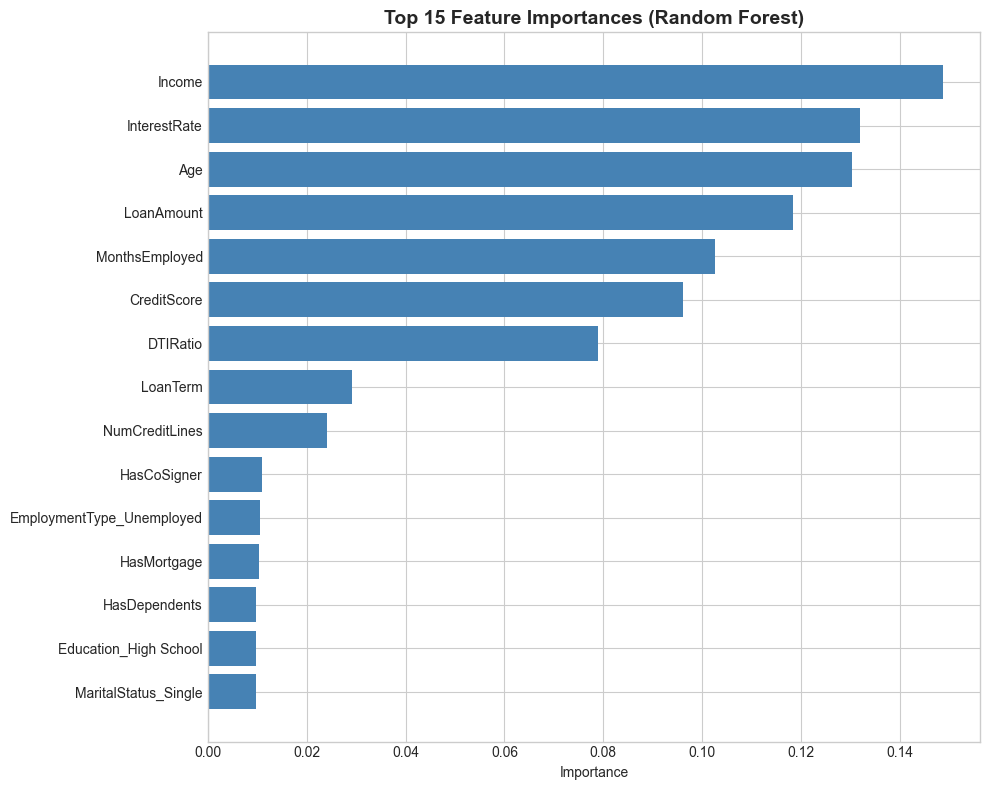


Top 10 Most Important Features:
       Feature  Importance
        Income    0.148752
  InterestRate    0.131926
           Age    0.130379
    LoanAmount    0.118439
MonthsEmployed    0.102667
   CreditScore    0.096046
      DTIRatio    0.078946
      LoanTerm    0.029131
NumCreditLines    0.024128
   HasCoSigner    0.010887


In [43]:
# 4. Feature Importance (Random Forest)
print("\n📊 Feature Importance (Random Forest)")
print("="*50)

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': grid_search_rf.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

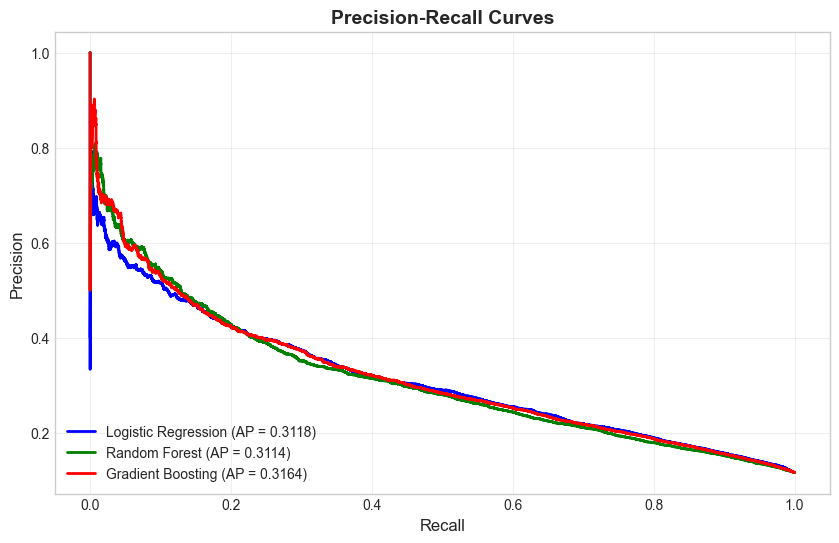

In [44]:
# 5. Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 6))

for (name, model), color in zip(models_for_roc, colors_roc):
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    avg_precision = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, color=color, lw=2, 
             label=f'{name} (AP = {avg_precision:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

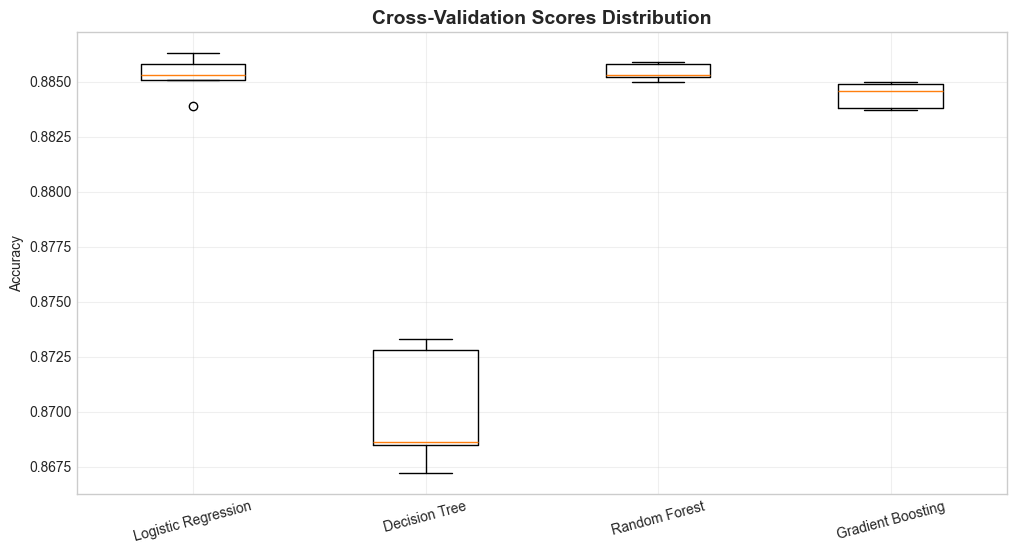

In [45]:
# 6. Cross-Validation Scores Box Plot
from sklearn.model_selection import cross_val_score

cv_results = {
    'Logistic Regression': cross_val_score(lr_sklearn, X_train_adv, y_train_adv, cv=5),
    'Decision Tree': cross_val_score(dt_clf, X_train_adv, y_train_adv, cv=5),
    'Random Forest': cross_val_score(grid_search_rf.best_estimator_, X_train_adv, y_train_adv, cv=5),
    'Gradient Boosting': cross_val_score(gb_clf, X_train_adv, y_train_adv, cv=5),
}

plt.figure(figsize=(12, 6))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.ylabel('Accuracy')
plt.title('Cross-Validation Scores Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
# Save the best model for Flask app
import pickle

# Save the best model (Gradient Boosting or Random Forest)
best_model_obj = grid_search_rf.best_estimator_  # or gb_clf

with open('loan_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
with open('features.pkl', 'wb') as f:
    pickle.dump(list(X_train.columns), f)

print("\n✅ Model, Scaler, and Features saved for Flask deployment!")
print("   - loan_model.pkl")
print("   - scaler.pkl")
print("   - features.pkl")


✅ Model, Scaler, and Features saved for Flask deployment!
   - loan_model.pkl
   - scaler.pkl
   - features.pkl
